In [1]:
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

To help in computing neutrino oscillation probabilities in real experimental setups, the `earth` module of Mag$\nu$s contains routines to compute the zenith angle of the location of one point on the surface of the Earth as measured from a different point, i.e., the position of a neutrino source measured from the position of a neutrino detector.  (These routines assume that the Earth is spherical, that the distribution of matter inside it radially symmetric, as in the Preliminary Reference Earth Model, and that the locations are on the surface, not underground.  Users can write their own functions to deal with these cases.)

The `earth` module contains predefined coordinates for a few significant locations:

In [2]:
earth.loc_coords_dms

{'baikal': {'lat': (51, 45, 54), 'lon': (104, 24, 54)},
 'cern': {'lat': (46, 14, 1.8), 'lon': (6, 3, 11.4)},
 'desy': {'lat': (53, 34, 19.79), 'lon': (9, 52, 27.59)},
 'ess': {'lat': (55, 44, 6), 'lon': (13, 15, 5.04)},
 'fermilab': {'lat': (41, 49, 55), 'lon': (-88, 15, 26)},
 'gran_sasso': {'lat': (42, 25, 15.8), 'lon': (13, 30, 58.43)},
 'homestake': {'lat': (44, 21, 5.76), 'lon': (-103, 45, 4.68)},
 'kamioka': {'lat': (36, 25, 50.05), 'lon': (137, 18, 41.15)},
 'km3net_arca': {'lat': (36, 16, 0), 'lon': (16, 6, 0)},
 'km3net_orca': {'lat': (42, 48, 0), 'lon': (6, 2, 0)},
 'north_pole': {'lat': (90, 0, 0), 'lon': (0, 0, 0)},
 'pyhaasalmi': {'lat': (63, 39, 31), 'lon': (26, 2, 28)},
 'snolab': {'lat': (46, 28, 18), 'lon': (-81, 11, 12)},
 'south_pole': {'lat': (-90, 0, 0), 'lon': (0, 0, 0)},
 'tokai': {'lat': (36, 27, 59), 'lon': (140, 36, 24)}}

The coordinates are tuples of (days, minutes, seconds).  This is the format in which the coordinates are pased to the functions below.  When defining custom locations, the user must feed them in this format to the functions.

Given the latitude (`lat`) and longitude (`lon`) of positions 1 (source) and 2 (detector) on the surface of the Earth, the chord length between them (i.e., the straight-line distance between them through the Earth) is computed with the `chord_length_inside_earth` function and the zenith angle of position 2 measured from position 1 is computed with the `costhz_between_points_on_surface` function.

In [3]:
# DUNE setup: from Fermilab (source) to Homestake (far detector)
lat1, lon1 = earth.loc_coords_dms['fermilab']['lat'], earth.loc_coords_dms['fermilab']['lon']
lat2, lon2 = earth.loc_coords_dms['homestake']['lat'], earth.loc_coords_dms['homestake']['lon']

baseline = earth.chord_length_inside_earth(lat1, lon1, lat2, lon2)
print("Baseline from Fermilab to Homestake: " + str(baseline) + " km")

costhz = earth.costhz_between_points_on_surface(lat1, lon1, lat2, lon2)
print("Cosine of zenith angle of Fermilab measured from Homestake: " + str(costhz))

Baseline from Fermilab to Homestake: 1207.1802288066992 km
Cosine of zenith angle of Fermilab measured from Homestake: -0.09474024712028718


Now that we know the zenith angle of the source as measured from the detector, we can compute and plot neutrino oscillation probabilities as usual (for details, see the example Mag$\nu$s notebooks `2_magnus_2nu_vacuum_matter.ipynb` and `3_magnus_3nu_vacuum_matter.ipynb` ).

To illustrate this, below, we consider an artificial setup of a neutrino beam with adjustable direction shot from Fermilab to several detector locations.

In [4]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Electron number density inside Earth, using the PREM density model
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # [eV^{-3}]

# Coherent forward potential inside Earth, using the PREM density model
def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

# Vacuum Hamiltonian without the 1/E prefactor 
H_vac_energy_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False)

# Hamiltonian including matter effects inside Earth using the PREM density model
def H_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return (1/energy)*H_vac_energy_indep + hamiltonians.hamiltonian_3nu_matter(VCC_func_prem(r))

# Cosines of zenith angles of Fermilab measured from the detector locations (we would get the same result if we seapped them, since we
# consider that Earth is radially symmetric)
detectors = ['SNOLAB', 'Homestake', 'CERN', "South Pole"]
costhz_arr = [earth.costhz_between_points_on_surface(earth.loc_coords_dms[det.lower().replace(" ", "_")]['lat'], 
                                                     earth.loc_coords_dms[det.lower().replace(" ", "_")]['lon'],
                                                     earth.loc_coords_dms['fermilab']['lat'], 
                                                     earth.loc_coords_dms['fermilab']['lon']) 
             for det in detectors]

# Maximum baselines inside the Earth
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] # [km]

# Helper function for labeling plots
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

# Per-detector colours and line styles, shared by both figures
lc = ['C0', 'C2', 'C3', 'C4']
ls = ['-', '-', '-', '-']


First, we compute the probabilities vs. baseline:

In [5]:
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.*gd.UNIT_MEV # [eV]

l_min = 1.e2 # [km]

# Generate probabilities for the different directions
distances_arr, prob_arr = [], []
l_npts = 3000
for i in range(len(costhz_arr)):
    print("detector = " + detectors[i])
    distances = np.logspace(np.log10(l_min), np.log10(l_max_arr[i]), l_npts) # [km
    distances_arr.append(distances)
    prob = np.array([oscprob.osc_prob(lambda ll: H_func_prem(costhz_arr[i], ll, energy), 0, l*gd.CONV_KM_TO_INV_EV,
                                      n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for l in distances]) 
    prob_arr.append(prob)

detector = SNOLAB


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


detector = Homestake


detector = CERN


detector = South Pole


Now we plot them, one panel per detector, with the electron-density profile
each trajectory samples stacked on top.

The profile panel is what makes the figure worth reading. Each baseline
crosses a different part of the Earth, so the four curves sample different
depths: the South Pole trajectory is the only one long enough to reach the
core, which is the step up to $N_e/N_{\rm Av} \approx 5.5$ near
$10^4$ km. Where that step falls along the baseline is exactly where the
corresponding probability curve changes character.

This is one call to `magnus.plotting.plot_probability_with_profile`; the
density panel, the shared logarithmic abscissa, the suppressed tick labels on
every panel but the last, and the legend styling are its defaults.

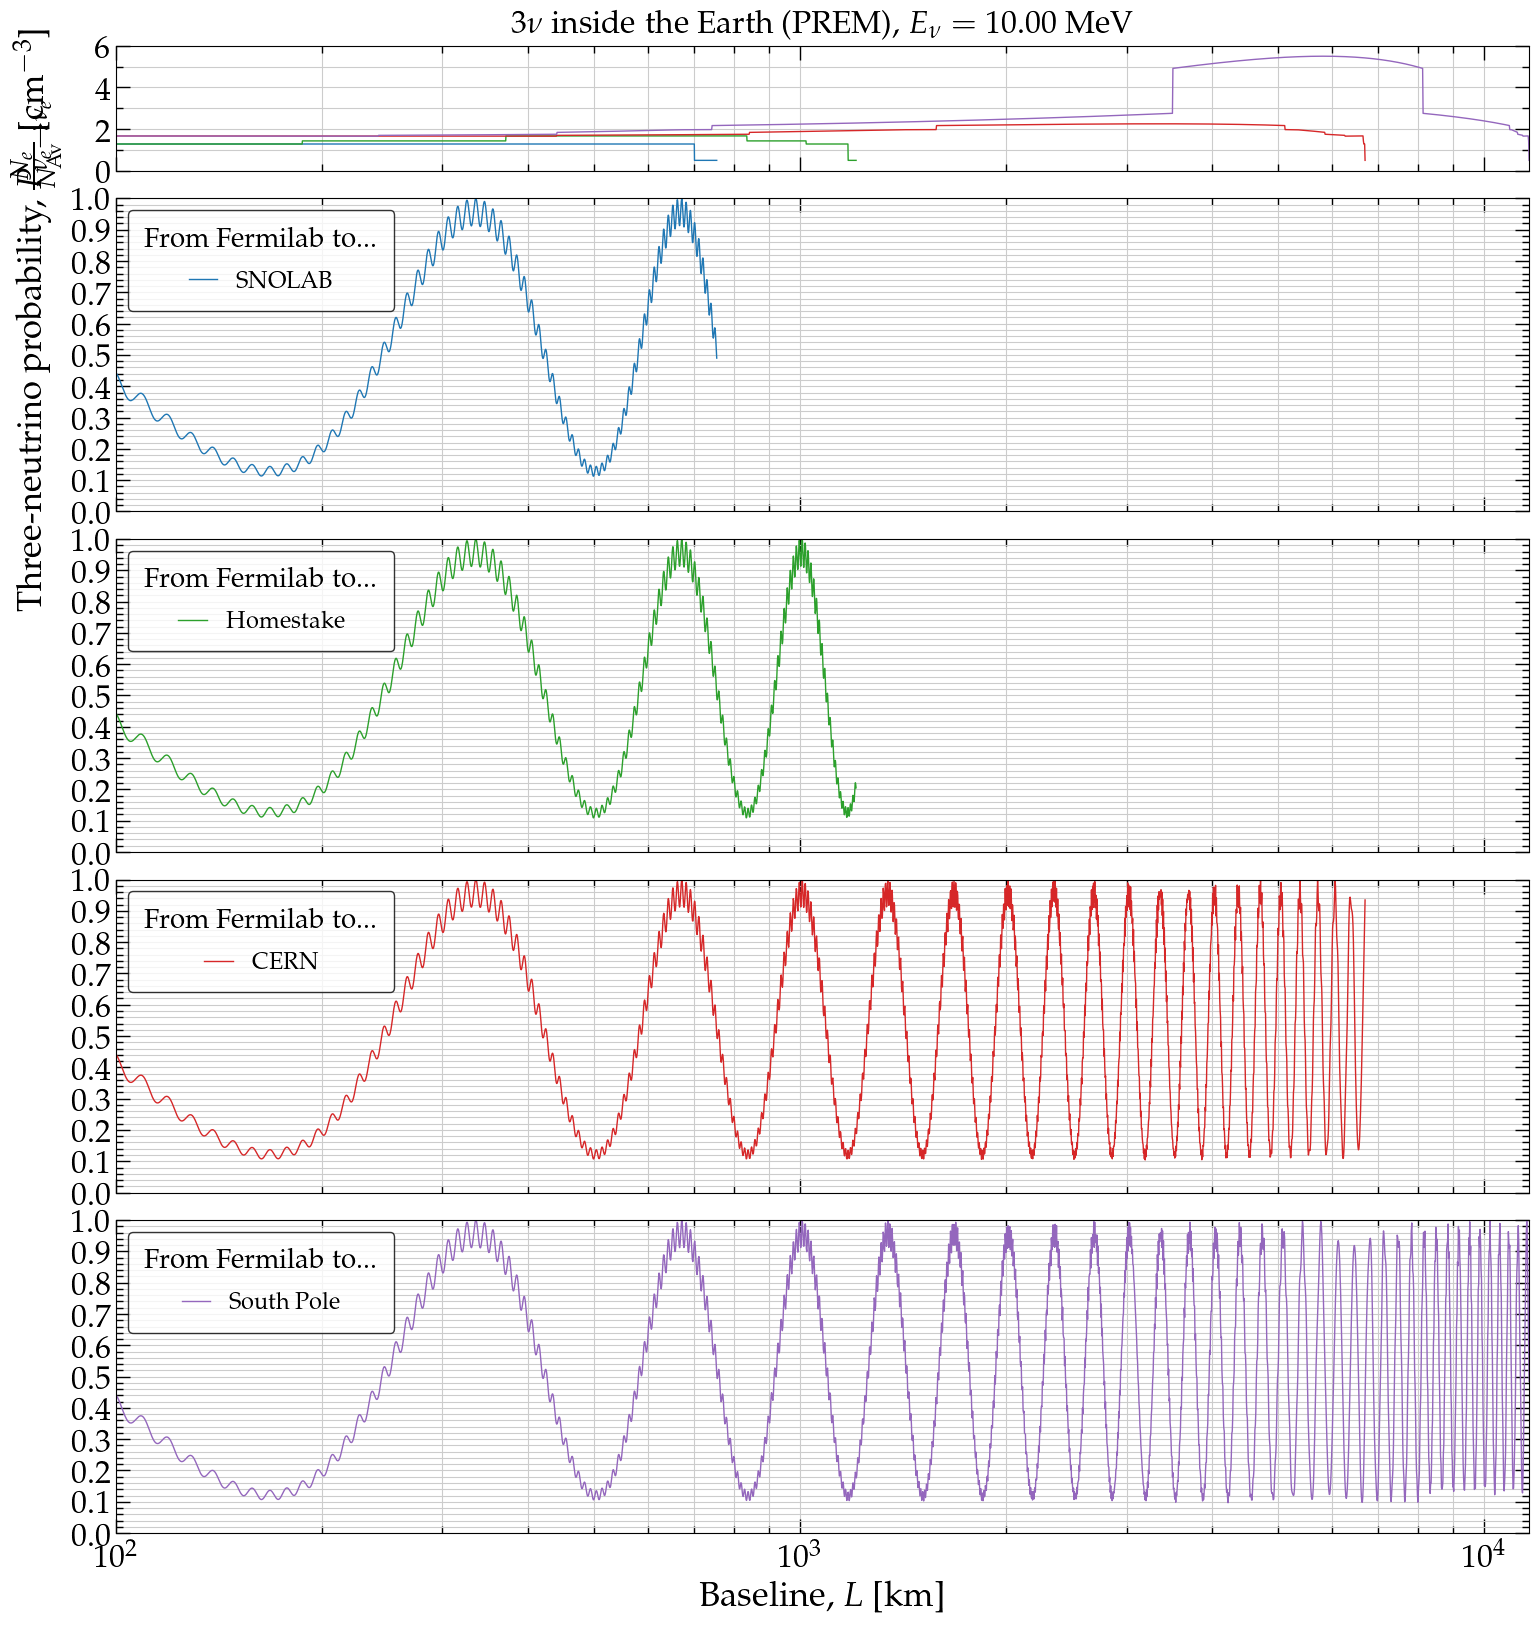

In [6]:
# The electron-density profile each trajectory samples, in units of N_Av, so
# that the panel reads directly as rho*Y_e in g cm^-3.
profiles, panels = [], []
for i in range(len(costhz_arr)):
    n_e = np.array([num_density_e_func_prem(
                        earth.earth_radial_distance_from_depth(costhz_arr[i], l))
                    for l in distances_arr[i]])
    n_e = n_e/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV, 3.0))
    profiles.append(dict(x=distances_arr[i], y=n_e, color=lc[i], ls=ls[i]))
    panels.append([dict(x=distances_arr[i], y=prob_arr[i], color=lc[i], ls=ls[i],
                        label=detectors[i])])

fig, ax = plotting.plot_probability_with_profile(
    distances_arr[0], profiles, panels,
    xlim=(l_min, max(l_max_arr)),
    profile_ylim=(0, 6), profile_ymajor=2, profile_yminor=1,
    panel_ymajor=0.10, panel_yminor=0.02,
    panel_ylabels=[r'Three-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]',
    title=r'$3\nu$~inside the Earth (PREM), $E_\nu = $~{:.2f}~MeV'.format(
        energy/gd.UNIT_MEV),
    legend_title=r'From Fermilab to...', legend_loc='upper left',
    legend_on_panel=-1, legend_kw=dict(borderpad=0.7, ncol=4),
    figsize=[18, 18])

Finally, we compute the probabilities vs. energy for the full baseline in each case:

In [7]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 3000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Generate probabilities for the different directions
prob_arr = []
for i in range(len(costhz_arr)):
    print("detector = " + detectors[i])
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_arr[i], l, enu*gd.UNIT_MEV), 
                                      0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_arr.append(prob)

detector = SNOLAB


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


detector = Homestake


detector = CERN


detector = South Pole


Finally, the same four trajectories against energy, at the full baseline in
each case.

Two panels: the probability as computed, and below it the same curve passed
through a Savitzky-Golay filter. The lower panel is not cosmetic. Above a few
tens of MeV the oscillation length falls well below any real detector's energy
resolution, so what an experiment measures is the local average, not the
fringes -- and the averaged curve is where the matter effect shows up as a
genuine, resolvable feature rather than as faster wiggles.

The same function draws it, with `profiles=None` to omit the density panel.

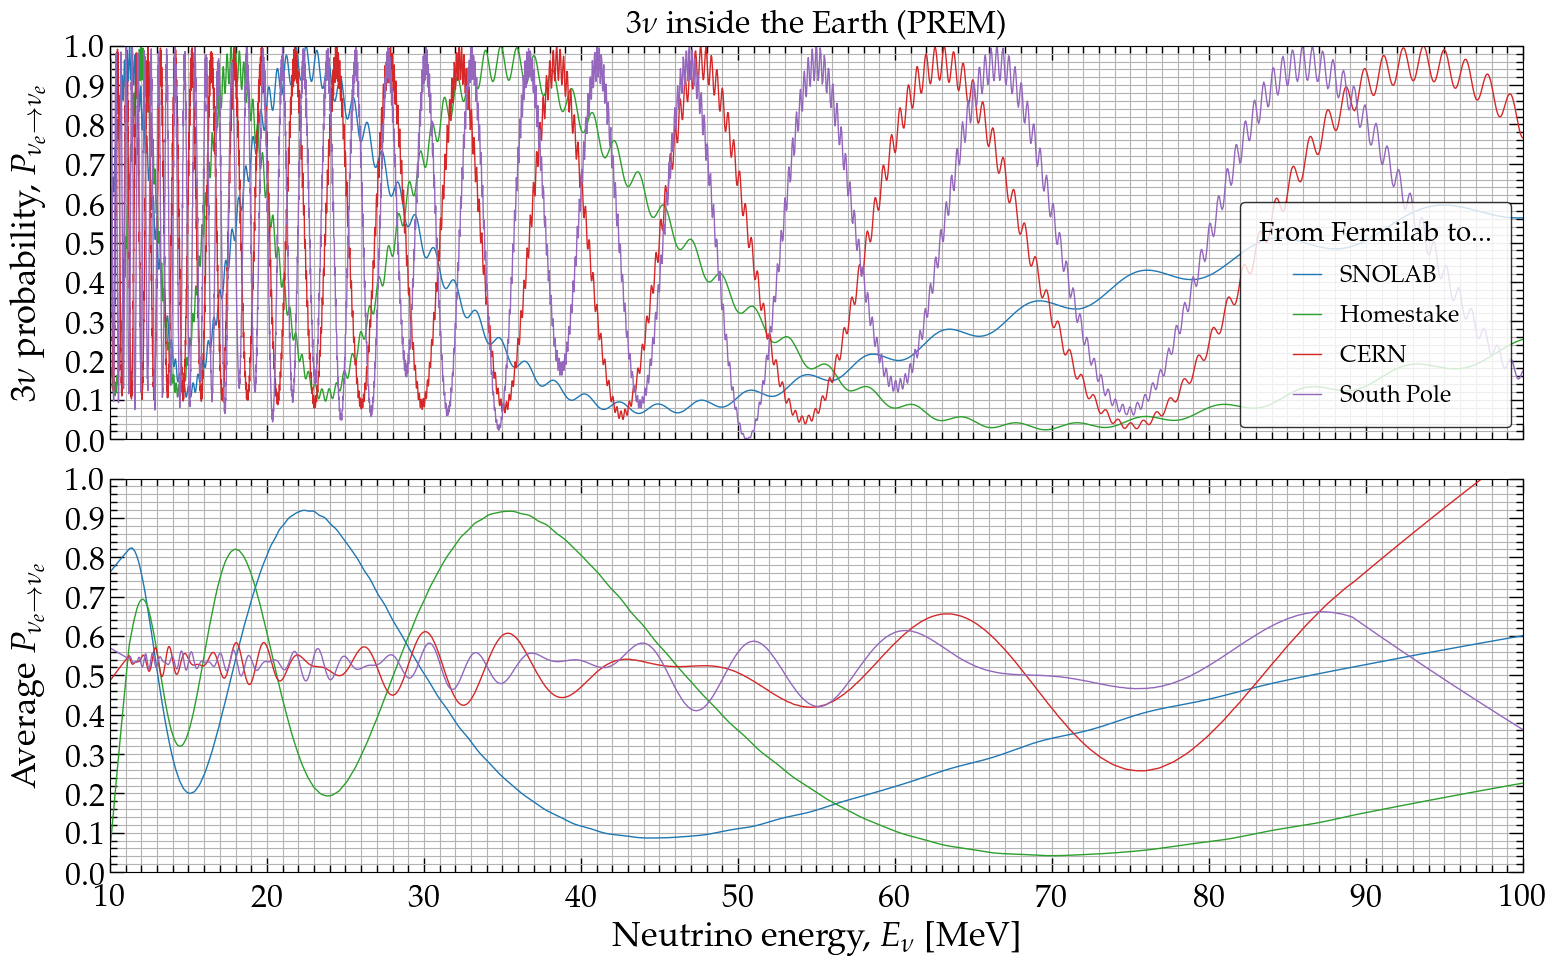

In [8]:
# No density panel this time: the lower panel is the same probability with the
# fast oscillations filtered out, which is what a detector with finite energy
# resolution actually measures.
fig, ax = plotting.plot_probability_with_profile(
    energies, None,
    [[dict(y=prob_arr[i], color=lc[i], ls=ls[i], label=detectors[i])
      for i in range(len(costhz_arr))],
     [dict(y=sp.signal.savgol_filter(prob_arr[i], window_length=301, polyorder=1),
           color=lc[i], ls=ls[i])
      for i in range(len(costhz_arr))]],
    xlim=(energy_min, energy_max), xscale='linear',
    xmajor=10, xminor=1, panel_ymajor=0.10, panel_yminor=0.02,
    panel_ylabels=[r'$3\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Neutrino energy, $E_\nu$ [MeV]',
    title=r'$3\nu$~inside the Earth (PREM)',
    legend_title=r'From Fermilab to...', legend_loc='lower right',
    legend_on_panel=0, grid_kw=dict(c='0.7'),
    figsize=[18, 10])